In [31]:
import geopandas as gpd

zones = gpd.read_file("data/maps/taxi_zones.shp")
print(zones.head())


   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1    0.116357    0.000782           Newark Airport           1   
1         2    0.433470    0.004866              Jamaica Bay           2   
2         3    0.084341    0.000314  Allerton/Pelham Gardens           3   
3         4    0.043567    0.000112            Alphabet City           4   
4         5    0.092146    0.000498            Arden Heights           5   

         borough                                           geometry  
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...  
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...  
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...  
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...  
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...  


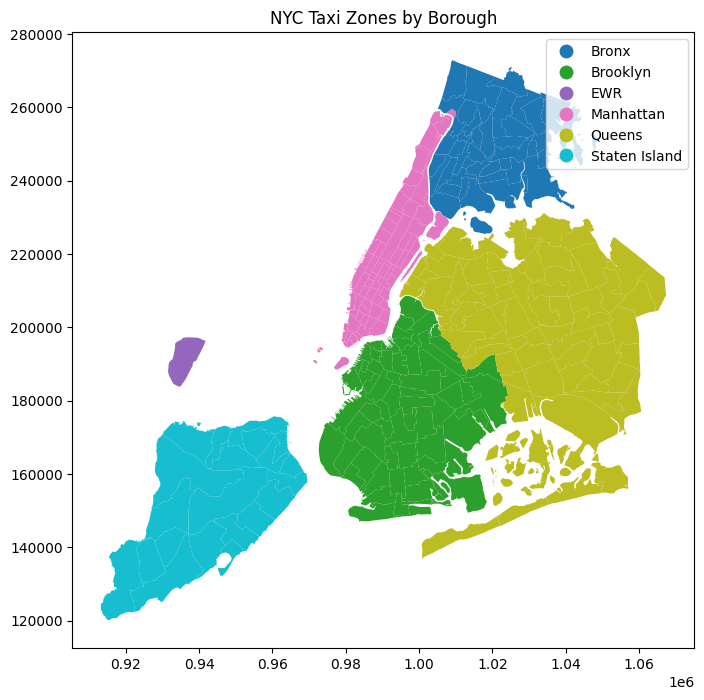

In [32]:
import matplotlib.pyplot as plt

zones.plot(column="borough", legend=True, figsize=(10, 8))
plt.title("NYC Taxi Zones by Borough")
plt.show()


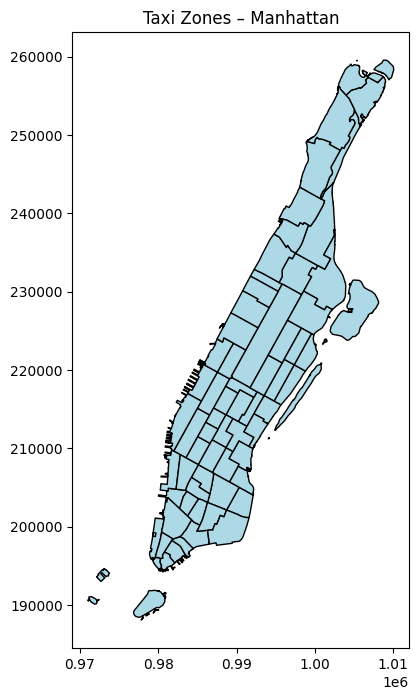

In [33]:
manhattan = zones[zones["borough"] == "Manhattan"]
manhattan.plot(color="lightblue", edgecolor="black", figsize=(8, 8))
plt.title("Taxi Zones – Manhattan")
plt.show()


In [34]:
lookup = zones[["LocationID", "borough", "zone"]]
print(lookup.head())

# Optional als CSV speichern
lookup.to_csv("taxi_zone_lookup.csv", index=False)


   LocationID        borough                     zone
0           1            EWR           Newark Airport
1           2         Queens              Jamaica Bay
2           3          Bronx  Allerton/Pelham Gardens
3           4      Manhattan            Alphabet City
4           5  Staten Island            Arden Heights


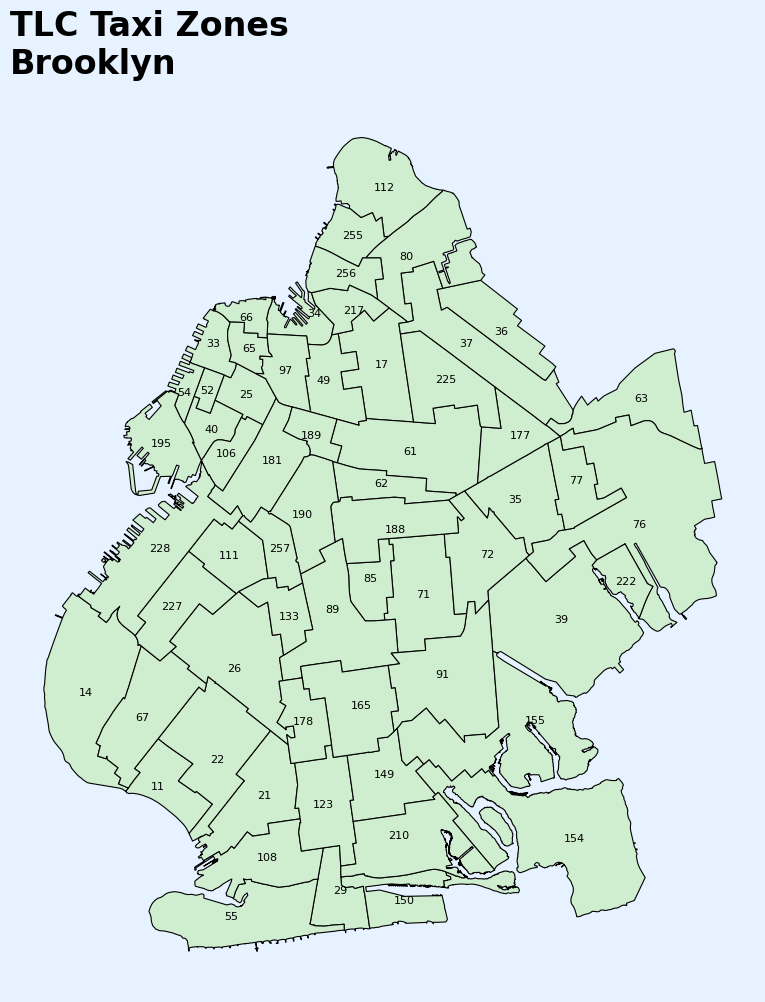

In [35]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Shapefile laden
zones = gpd.read_file("data/maps/taxi_zones.shp")

# 2) Nur Brooklyn und in Meter-Projektion (für saubere Labels/Skalierung)
bk = zones[zones["borough"] == "Brooklyn"].to_crs(3857)  # Web Mercator (Meter)

# 3) Repräsentative Punkte für Labels (fallen sicher ins Polygon)
bk["label_pt"] = bk.geometry.representative_point()

# 4) Plot
fig, ax = plt.subplots(figsize=(8, 10), facecolor="#e6f2ff")  # hellblauer Rand/Wasser
ax.set_facecolor("#e6f2ff")

# Füllung + Ränder
bk.plot(ax=ax, color="#cfeecf", edgecolor="black", linewidth=0.8)

# 5) Labels (LocationID) setzen
for _, r in bk.iterrows():
    x, y = r["label_pt"].x, r["label_pt"].y
    ax.text(x, y, str(r["LocationID"]), ha="center", va="center", fontsize=8)

# 6) Titel links oben
ax.set_title("TLC Taxi Zones\nBrooklyn", loc="left", fontsize=24, weight="bold")

# 7) Achsen aus
ax.set_axis_off()
plt.tight_layout()
plt.show()


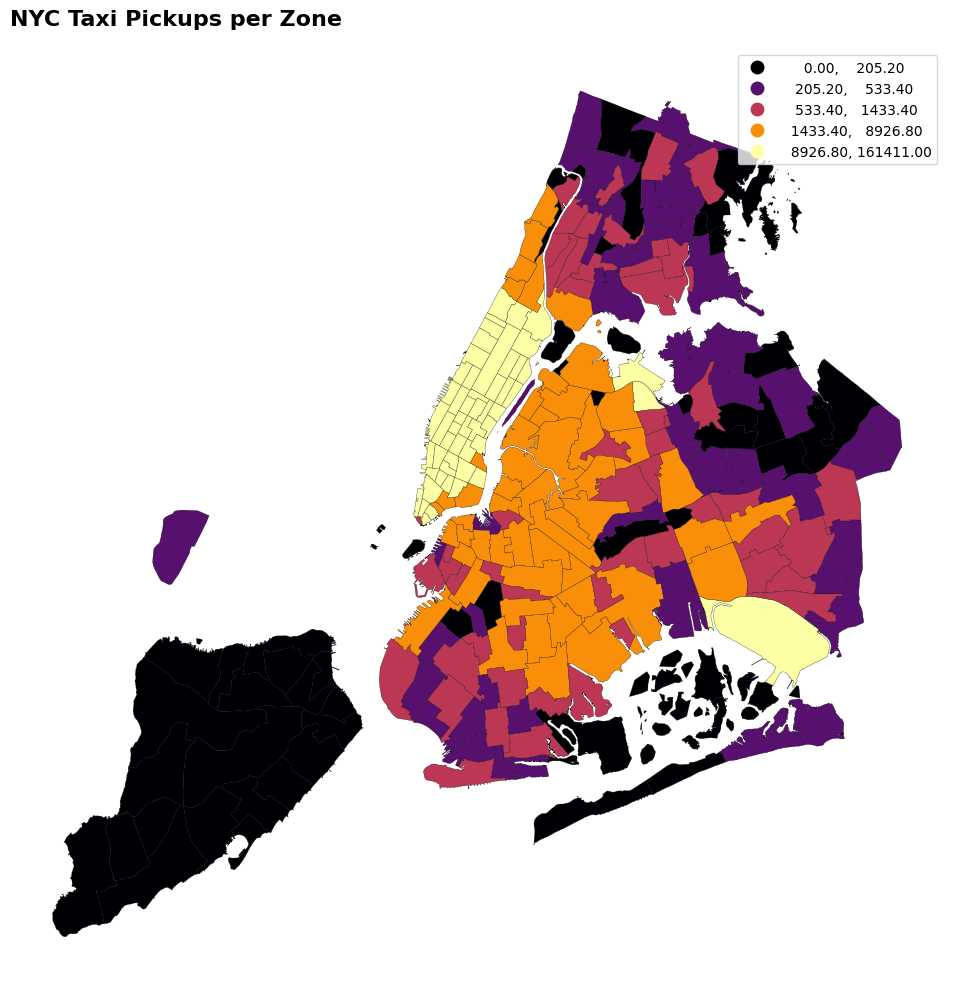

In [36]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ---- 1) Zonen laden
zones = gpd.read_file("data/maps/taxi_zones.shp")[["LocationID","borough","zone","geometry"]]

# ---- 2) Tripdaten laden (nur die Spalte, aus mehreren Dateien aggregieren möglich)
# Beispiel: Pickups pro Zone
files = [
    "data/parquet/yellow_tripdata_2025-02.parquet",
    # weitere Dateien hier ergänzen …
]
counts = []
for f in files:
    df = pd.read_parquet(f, columns=["PULocationID"])
    counts.append(df["PULocationID"].value_counts())

pickup_counts = pd.concat(counts, axis=0).groupby(level=0).sum()
pickup_counts = pickup_counts.rename_axis("LocationID").reset_index(name="pickups")

# ---- 3) Join mit Geometrie
g = zones.merge(pickup_counts, on="LocationID", how="left").fillna({"pickups":0})

# ---- 4) Plotten (Choropleth)
g3857 = g.to_crs(3857)  # Meterprojektion für sauberes Rendering
ax = g3857.plot(
    column="pickups",
    cmap="inferno",
    scheme="quantiles",  # oder "naturalbreaks"
    k=5,
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    figsize=(10,10)
)
ax.set_axis_off()
ax.set_title("NYC Taxi Pickups per Zone", loc="left", fontsize=16, weight="bold")
plt.tight_layout(); plt.show()


In [37]:
import pandas as pd
import geopandas as gpd
import folium
from folium.plugins import HeatMap

# Zonen für Umriss (optional)
zones = gpd.read_file("data/maps/taxi_zones.shp").to_crs(4326)

# Tripdaten mit Lat/Lon (Spaltennamen je nach Jahr anpassen!)
df = pd.read_parquet("data/parquet/yellow_tripdata_2025-02.parquet",
                     columns=["pickup_latitude","pickup_longitude"])
df = df.dropna()
points = df[["pickup_latitude","pickup_longitude"]]
points = points[(points["pickup_latitude"].between(40.4,41.0)) &
                (points["pickup_longitude"].between(-74.3,-73.5))]

m = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# optional: Umriss zeichnen
folium.GeoJson(zones).add_to(m)

HeatMap(points.values.tolist(), radius=8, blur=12, max_zoom=13).add_to(m)
m  # wird im Notebook angezeigt


ArrowInvalid: No match for FieldRef.Name(pickup_latitude) in VendorID: int32
tpep_pickup_datetime: timestamp[us]
tpep_dropoff_datetime: timestamp[us]
passenger_count: int64
trip_distance: double
RatecodeID: int64
store_and_fwd_flag: large_string
PULocationID: int32
DOLocationID: int32
payment_type: int64
fare_amount: double
extra: double
mta_tax: double
tip_amount: double
tolls_amount: double
improvement_surcharge: double
total_amount: double
congestion_surcharge: double
Airport_fee: double
cbd_congestion_fee: double
__fragment_index: int32
__batch_index: int32
__last_in_fragment: bool
__filename: string